# Proyecto Final: Sistema de Recomendación Híbrido de Laptops

Este notebook presenta la fundamentación matemática y la implementación paso a paso de un **Sistema de Recomendación Híbrido de Laptops** en dos niveles:
1. **Filtro en Cascada (Cascade Filtering)**: Usando reglas de inferencia lógica basadas en restricciones duras de hardware.
2. **Ensamble Ponderado Dinámico (Dynamic Weighted Ensemble)**: Combinando tres modelos complementarios (MAUT, SVD y Similaridad Coseno) con coeficientes adaptables según el perfil de usuario.

## 🧩 Los 4 Sub-Modelos del Sistema Híbrido

### 🟢 Modelo 1: Motor de Inferencia Lógica (Constraint-Based)
Evalúa reglas duras (vías máscara binaria $M_{rules}(i) \in \{0, 1\}$) para descartar opciones técnicamente inviables según el caso de uso y el presupuesto.
$$M_{rules}(i) = \begin{cases} 1 & \text{si cumple todas las reglas duras} \\ 0 & \text{si viola al menos una regla} \end{cases}$$

### 🔵 Modelo 2: Multi-Attribute Utility Theory (MAUT) Score (Knowledge-Based)
Normaliza las especificaciones (precio, rendimiento, portabilidad, pantalla) y aplica una función de utilidad ponderada por sliders:
$$U_{Knowledge}(i) = w_{price} \cdot S_{price}(i) + w_{perf} \cdot S_{perf}(i) + w_{portability} \cdot S_{portability}(i) + w_{screen} \cdot S_{screen}(i)$$

### 🟣 Modelo 3: Matrix Factorization mediante SVD (Collaborative Filtering)
Predice valoraciones implícitas basadas en la comunidad de usuarios similares usando descomposición de factores latentes optimizada con SGD:
$$\hat{r}_{u,i} = \mu + b_u + b_i + P_u^T Q_i$$

### 🔴 Modelo 4: Similitud Coseno de Atributos (Content-Based Vector Embedding)
Vectoriza las especificaciones técnicas ($v_i$) y calcula el ángulo del coseno respecto al vector de perfil del usuario ($v_u$):
$$S_{content}(i) = \cos(v_u, v_i) = \frac{v_u \cdot v_i}{\|v_u\| \|v_i\|}$$

---

## 1. Configuración del Entorno de Ejecución
Agregamos el directorio raíz del proyecto al `sys.path` para importar correctamente los módulos locales.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Agregar directorio padre al path
parent_dir = os.path.dirname(os.path.abspath(''))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Directorio raíz configurado:", parent_dir)

Directorio raíz configurado: E:\X SEMESTER\Sistemas de Recomendaacion\sr2\proyectofinal_SR


## 2. Inicialización de Datos
Cargamos los DataFrames de laptops y calificaciones de usuarios. Si no existen, los generamos de forma sintética.

In [2]:
from src.data_generator import generate_datasets

laptops_path = "../data/laptops.csv"
ratings_path = "../data/ratings.csv"

if not os.path.exists(laptops_path) or not os.path.exists(ratings_path):
    print("Generando nuevos datasets sintéticos...")
    generate_datasets(dest_dir="../data")
else:
    print("Datasets encontrados en la ruta especificada.")

laptops_df = pd.read_csv(laptops_path)
ratings_df = pd.read_csv(ratings_path)

print(f"Total Laptops: {len(laptops_df)}")
print(f"Total Calificaciones (Interacciones): {len(ratings_df)}")

Datasets encontrados en la ruta especificada.
Total Laptops: 150
Total Calificaciones (Interacciones): 1999


### Vista Previa del Catálogo de Laptops

In [3]:
laptops_df.head(3)

,id,brand,name,price,cpu,cpu_cores,ram,gpu,gpu_vram,dedicated_gpu,...,rating_avg,best_store,historical_low,historical_high,historical_avg,price_trend_tag,price_history_json,buy_url,amazon_url,description
0,1,ASUS,ASUS ROG Strix G16 (8GB RAM),1552,Intel Core i9-13980HX,24,8,NVIDIA RTX 4070,8,True,...,3.92,PC Componentes,1378,1745,1557,Precio regular (Prom: $1557 USD),"[1745, 1665, 1601, 1557, 1424, 1552]",https://www.pccomponentes.com/buscar/?query=la...,https://www.amazon.com/s?k=ASUS+ROG+Strix+G16+8GB,Laptop ASUS diseñada para uso tipo gaming con ...
1,2,ASUS,ASUS ROG Zephyrus G14 (8GB RAM),1848,AMD Ryzen 9 7940HS,8,8,NVIDIA RTX 4060,8,True,...,4.86,PC Componentes,1584,2029,1827,Precio regular (Prom: $1827 USD),"[2029, 1942, 1868, 1827, 1649, 1848]",https://www.pccomponentes.com/buscar/?query=la...,https://www.amazon.com/s?k=ASUS+ROG+Zephyrus+G...,Laptop ASUS diseñada para uso tipo gaming_ligh...
2,3,MSI,MSI Katana 15 (32GB RAM),1154,Intel Core i7-13620H,10,32,NVIDIA RTX 4060,8,True,...,4.18,Amazon.com,1059,1273,1160,1% por debajo del promedio ($1160 USD),"[1273, 1214, 1200, 1160, 1096, 1154]",https://www.amazon.com/s?k=MSI+Katana+15+32GB,https://www.amazon.com/s?k=MSI+Katana+15+32GB,Laptop MSI diseñada para uso tipo gaming con p...


### Vista Previa de la Matriz de Ratings de Usuarios

In [4]:
ratings_df.head(5)

,user_id,laptop_id,rating
0,U001,96,3
1,U001,138,3
2,U001,43,5
3,U001,139,4
4,U001,1,2


## 3. Pruebas del Modelo 1: Motor de Inferencia Lógica
Evaluamos el funcionamiento de las reglas declarativas sobre un perfil demandante: `Deep Learning` (VRAM >= 6GB, RAM >= 16GB, CUDA = True) con un presupuesto de 1500 USD.

In [5]:
from src.rules_engine import LogicInferenceModel

rules_model = LogicInferenceModel("../data/knowledge_rules.json")

usage = "Deep Learning"
budget = 1500.0

mask = rules_model.get_binary_mask(laptops_df, usage, budget)
print(f"Laptops viables de hardware y presupuesto: {sum(mask)} de {len(laptops_df)}")

# Mostrar las laptops que pasaron las reglas duras
laptops_df[mask == 1][["brand", "name", "price", "ram", "gpu_vram", "cuda_support"]].head(5)

Laptops viables de hardware y presupuesto: 25 de 150


,brand,name,price,ram,gpu_vram,cuda_support
2,MSI,MSI Katana 15 (32GB RAM),1154,32,8,True
5,Lenovo,Lenovo Legion Slim 5 (16GB RAM),1202,16,6,True
8,Acer,Acer Nitro V 15 (16GB RAM),927,16,6,True
9,HP,HP Victus 16 (16GB RAM),1013,16,6,True
11,Gigabyte,Gigabyte G5 KF (32GB RAM),1062,32,8,True


## 4. Pruebas del Modelo 2: MAUT Utility Score
Calculamos el puntaje de utilidad multi-atributo para las laptops basándonos en sliders de preferencias cualitativas del usuario (e.g. prioridad en precio bajo y rendimiento).

In [6]:
from src.maut_model import MAUTModel

maut_model = MAUTModel()
maut_model.fit(laptops_df)

# Pesos asignados por el usuario (Precio y Rendimiento alta prioridad)
weights = {
    "price": 0.4,
    "perf": 0.4,
    "portability": 0.1,
    "screen": 0.1
}

utility_scores = maut_model.compute_utility(laptops_df, weights)
laptops_df_u = laptops_df.copy()
laptops_df_u["maut_utility"] = utility_scores

print("Top 5 Laptops con mayor utilidad MAUT:")
laptops_df_u.sort_values(by="maut_utility", ascending=False)[["name", "price", "ram", "gpu_vram", "weight", "maut_utility"]].head(5)

Top 5 Laptops con mayor utilidad MAUT:


,name,price,ram,gpu_vram,weight,maut_utility
101,Gigabyte G5 KF (32GB RAM),971,32,8,1.98,0.672641
11,Gigabyte G5 KF (32GB RAM),1062,32,8,2.03,0.658279
39,HP Victus 16 (32GB RAM),1001,32,6,2.24,0.652373
69,HP Victus 16 (32GB RAM),1006,32,6,2.32,0.647974
129,HP Victus 16 (32GB RAM),1104,32,6,2.32,0.635024


## 5. Pruebas del Modelo 3: Matrix Factorization SVD
Entrenamos el SVD colaborativo usando SGD en numpy y predecimos la valoración implícita del usuario U001 en laptop con ID 5.

In [7]:
from src.svd_model import MatrixFactorizationSVD

svd_model = MatrixFactorizationSVD()
svd_model.fit(ratings_df)

user_id = "U001"
laptop_id = 5

rating_pred = svd_model.predict(user_id, laptop_id)
rating_pred_norm = svd_model.predict_normalized(user_id, laptop_id)

print(f"Predicción de rating para el usuario {user_id} e item {laptop_id}:")
print(f"Rating original (1-5 estrellas): {rating_pred:.2f}★")
print(f"Rating normalizado (0-1): {rating_pred_norm:.4f}")


Modelo SVD entrenado sobre 1999 valoraciones.
Predicción de rating para el usuario U001 e item 5:
Rating original (1-5 estrellas): 3.90★
Rating normalizado (0-1): 0.7249


## 6. Pruebas del Modelo 4: Similitud Coseno de Atributos (Content-Based)
Calculamos la similitud coseno entre las laptops y un vector ideal teórico del usuario según sus preferencias de hardware y portabilidad.

In [8]:
from src.content_model import ContentBasedModel

content_model = ContentBasedModel()
content_model.fit(laptops_df)

cosine_similarities = content_model.compute_similarity(laptops_df, "Deep Learning", 1500.0, weights)
laptops_df_c = laptops_df.copy()
laptops_df_c["cosine_similarity"] = cosine_similarities

print("Top 5 Laptops con mayor similitud de contenido a la ideal del usuario:")
laptops_df_c.sort_values(by="cosine_similarity", ascending=False)[["name", "price", "ram", "gpu_vram", "weight", "cosine_similarity"]].head(5)

Top 5 Laptops con mayor similitud de contenido a la ideal del usuario:


,name,price,ram,gpu_vram,weight,cosine_similarity
67,Acer Predator Helios 16 (32GB RAM),1605,32,8,2.62,0.943989
96,Razer Blade 16 (32GB RAM),3140,32,12,2.51,0.924781
2,MSI Katana 15 (32GB RAM),1154,32,8,2.35,0.923170
122,MSI Katana 15 (32GB RAM),1116,32,8,2.34,0.922633
11,Gigabyte G5 KF (32GB RAM),1062,32,8,2.03,0.922175


## 7. Pruebas del Ensamble Híbrido Final
Instanciamos el recomendador híbrido global y evaluamos dos perfiles diferentes para demostrar la **Ponderación Adaptable Dinámica**:
1. **Usuario Nuevo (Cold Start)**: Da prioridad a MAUT y Contenido, bajando el peso de SVD.
2. **Usuario Recurrente**: Da prioridad al SVD colaborativo.

In [9]:
from src.hybrid_recommender import HybridRecommender

hybrid_rec = HybridRecommender(data_dir="../data")
hybrid_rec.load_data_and_train()

user_known = "U001"
user_new = "U999"
usage = "Deep Learning"
budget = 1600.0
weights = {"price": 0.2, "perf": 0.6, "portability": 0.1, "screen": 0.1}

Modelo SVD entrenado sobre 1999 valoraciones.


In [10]:
# 1. Caso Cold Start (Usuario Nuevo)
recs_new, meta_new = hybrid_rec.get_recommendations(user_new, usage, budget, weights, top_k=5, is_cold_start=True)
print("=== RECOMENDACIONES COLD START (NUEVO USUARIO) ===")
print(f"Perfil aplicado: {meta_new['profile_type']}")
print(f"Pesos: {meta_new['weights']}\n")
print(recs_new[["name", "price", "u_knowledge", "s_content", "svd_score_norm", "hybrid_score"]])

=== RECOMENDACIONES COLD START (NUEVO USUARIO) ===
Perfil aplicado: Cold Start (Usuario Nuevo)
Pesos: {'alpha_maut': 0.6, 'beta_svd': 0.1, 'gamma_content': 0.3}

                          name  price  u_knowledge  s_content  svd_score_norm  \
101  Gigabyte G5 KF (32GB RAM)    971     0.626193   0.917630        0.914646   
11   Gigabyte G5 KF (32GB RAM)   1062     0.617844   0.920593        0.932618   
129    HP Victus 16 (32GB RAM)   1104     0.593363   0.914478        0.783266   
32    MSI Katana 15 (32GB RAM)   1189     0.581639   0.918440        0.775271   
2     MSI Katana 15 (32GB RAM)   1154     0.578812   0.921651        0.773439   

     hybrid_score  
101      0.742469  
11       0.740146  
129      0.708688  
32       0.702043  
2        0.701126  


In [11]:
# 2. Caso Usuario Frecuente (Colaborativo)
recs_known, meta_known = hybrid_rec.get_recommendations(user_known, usage, budget, weights, top_k=5, is_cold_start=False)
print("=== RECOMENDACIONES USUARIO CON HISTORIAL ===")
print(f"Perfil aplicado: {meta_known['profile_type']}")
print(f"Pesos: {meta_known['weights']}\n")
print(recs_known[["name", "price", "u_knowledge", "s_content", "svd_score_norm", "hybrid_score"]])

=== RECOMENDACIONES USUARIO CON HISTORIAL ===
Perfil aplicado: Usuario Frecuente (Colaborativo)
Pesos: {'alpha_maut': 0.3, 'beta_svd': 0.5, 'gamma_content': 0.2}

                           name  price  u_knowledge  s_content  \
11    Gigabyte G5 KF (32GB RAM)   1062     0.617844   0.920593   
101   Gigabyte G5 KF (32GB RAM)    971     0.626193   0.917630   
68   Acer Nitro V 15 (32GB RAM)    940     0.559437   0.883418   
71    Gigabyte G5 KF (16GB RAM)   1009     0.523629   0.877854   
131   Gigabyte G5 KF (16GB RAM)    867     0.525534   0.883553   

     svd_score_norm  hybrid_score  
11         0.989512      0.864228  
101        0.980590      0.861679  
68         0.975446      0.832238  
71         0.986274      0.825796  
131        0.971736      0.820239  


## 8. Evaluación Científica del Sistema
Ejecutamos la rutina de evaluación científica y cargamos los gráficos comparativos de rendimiento. 
Esto nos permite ver el **Constraint Satisfaction Rate (CSR)** y **Precision/Recall** frente a baselines independientes.

In [12]:
from src.evaluation import evaluate_metrics

metrics_results = evaluate_metrics(data_dir="../data", output_plot_dir="../app/static/plots")

print("\n--- RESULTADOS FINALES DE EVALUACIÓN ---")
for key, val in metrics_results.items():
    print(f"{key}: {val:.4f}")

Modelo SVD entrenado sobre 1596 valoraciones.
SVD Test RMSE: 1.1233


Modelo SVD entrenado sobre 1999 valoraciones.
CSR@10 Hybrid: 100.0%
CSR@10 SVD Pure: 55.0%
CSR@10 Content Pure: 61.7%


Hybrid Precision@10: 0.0619, Recall@10: 0.1818
SVD Pure Precision@10: 0.0444, Recall@10: 0.1302
Gráficos de evaluación generados y guardados en app/static/plots/

--- RESULTADOS FINALES DE EVALUACIÓN ---
svd_rmse: 1.1233
csr_hybrid: 1.0000
csr_svd: 0.5500
csr_content: 0.6167
precision_hybrid: 0.0619
recall_hybrid: 0.1818
precision_svd: 0.0444
recall_svd: 0.1302


<Figure size 800x500 with 0 Axes>

### Visualización de Gráficos de Evaluación

1. Tasa de Satisfacción de Restricciones (CSR@10):


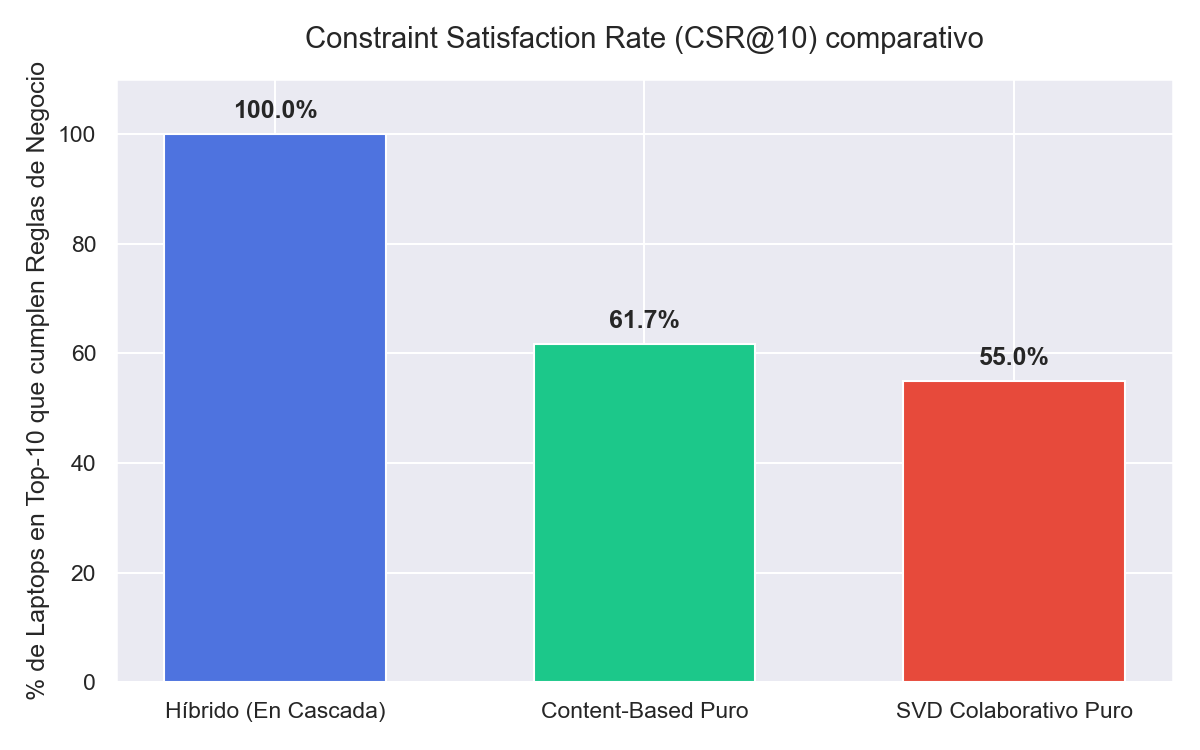


2. Precisión y Recall Comparativo vs Baseline:


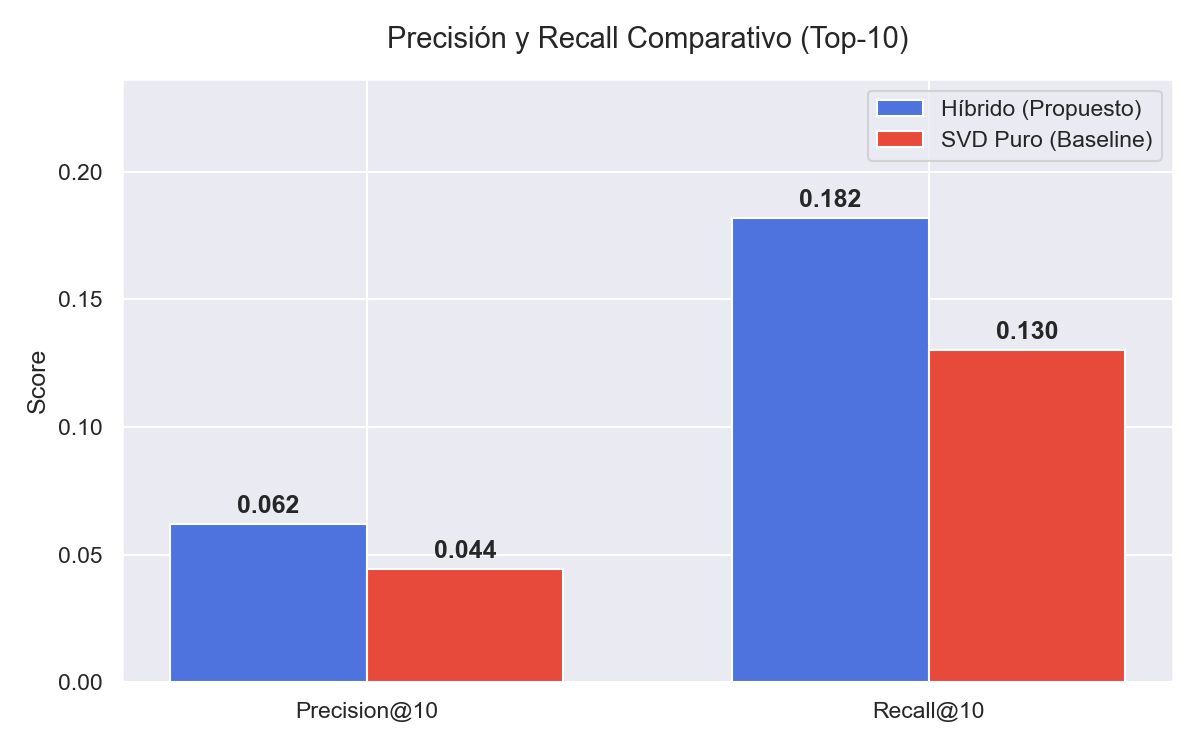

In [13]:
from IPython.display import Image, display

print("1. Tasa de Satisfacción de Restricciones (CSR@10):")
display(Image(filename="../app/static/plots/evaluation_csr.png"))

print("\n2. Precisión y Recall Comparativo vs Baseline:")
display(Image(filename="../app/static/plots/evaluation_precision_recall.png"))